# Lab 1: Introduction to Digital Images and Image Processing with Python
**Course:** AI342 Image Processing  
**University:** Taibah University  
**College:** Computer Science and Engineering  
**Department:** AI & DS
---
### Learning Objectives:
* Represent a digital image as a numerical array.
* Understand pixels, spatial resolution, and grey level intensity.
* Load, display, and inspect images in Python.
* Apply simple low-level image processing operations.
* Relate practical operations to the image processing pipeline introduced in Chapter 1

## 1. Environment Setup

In [18]:
# write your code here
import numpy as np
import matplotlib.pyplot as plt
import cv2




## 2. What is a digital image in practice?
In the lecture, a digital image is defined as a two dimensional function $f(x,y)$ where the value at each coordinate represents intensity. In practice, this function is stored as a matrix of numbers.

##**Exercise 2.1: Create a synthetic image**


In [19]:
# Task: Create an 8x8 black image (matrix of zeros)
# Hint: Use np.zeros((rows, cols))
image = np.zeros((8, 8))
print(image)




# --- Discussion Questions ---
# 1. What is the spatial resolution of this image?
# the resolution is 8 x 8 times, which means the image is a grid of 64 pixels in total.
# 2. What does each value represent?
# Each value is the intensity of a pixel. Since they are all 0, the whole image is just black.

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


##**Exercise 2.2: Visualise the image**

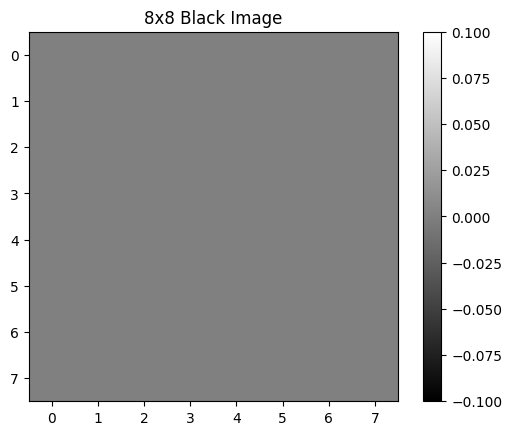

In [20]:
# write your code here
plt.imshow(image, cmap='gray')
plt.title("8x8 Black Image")
plt.colorbar()
plt.show()

# Task: Change some pixels to 255 (White) and re-visualize
# image[row, col] = 255
# WRITE YOUR CODE HERE:

## 3. Pixels and intensity values
Pixels are the smallest units of a digital image and hold quantised intensity values, as discussed in the slides on pixels and digitisation
## **Exercise 3.1: Modify individual pixels**


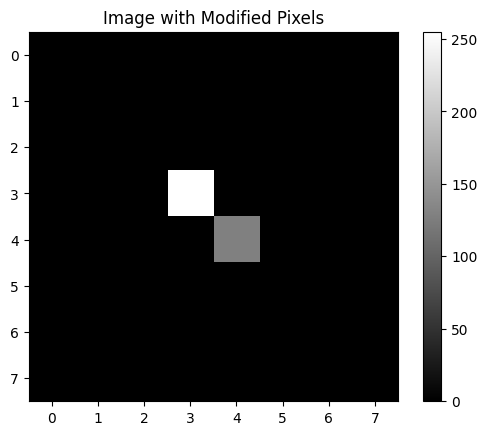

In [21]:
# write your code here
image[3, 3] = 255
image[4, 4] = 128

plt.imshow(image, cmap='gray')
plt.title("Image with Modified Pixels")
plt.colorbar()
plt.show()


#Questions
#1.	Which pixel is brighter and why?
# Pixel [3, 3] is brighter because 255 is the highest possible value (white), while [4, 4] is only 128 (gray).
#2.	How does quantisation affect visual appearance?
# It decides how many gray levels we have. Low quantization makes the image look "blocky" with visible jumps between colors.


## 4. Grey scale images
The course focuses primarily on grey scale images with one sample per pixel.
## **Exercise 4.1: Generate a gradient image**


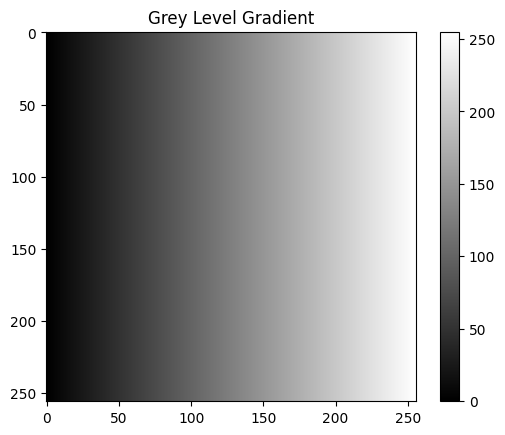

In [22]:
# write your code here
gradient = np.tile(np.linspace(0, 255, 256), (256, 1))

plt.imshow(gradient, cmap='gray')
plt.title("Grey Level Gradient")
plt.colorbar()
plt.show()

#Questions
#1.	How many grey levels are visible?
# There are 256 levels, going from 0 (black) all the way up to 255 (white).
#2.	What data type is used to store the pixel values?
# It's uint 8 because it stores 8-bit integers from 0 to 255.


## 5. Image acquisition and representation
Image acquisition converts a physical scene into a digital image. In Python, loading an image is equivalent to acquiring an already digitised scene.
## **Exercise 5.1: Load and inspect an image**

(675, 1200, 3)
uint8


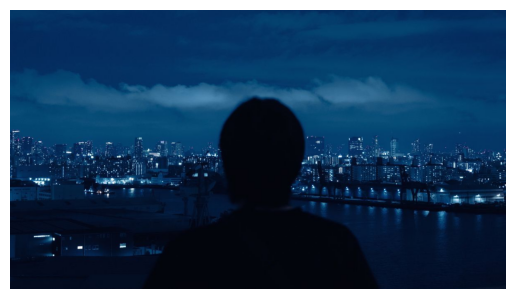

In [23]:
# write your code here
from matplotlib.image import imread
import matplotlib.pyplot as plt

image = imread('/content/a5dac4c4d4f05cab200ac871f67aef2d.jpg')

print(image.shape)
print(image.dtype)

plt.imshow(image)
plt.axis('off')
plt.show()


## 6. Low level image processing: image in, image out
Low level processing improves visual quality without extracting semantic meaning, as described in the lecture pipeline
## **Exercise 6.1: Image enhancement by contrast stretching**

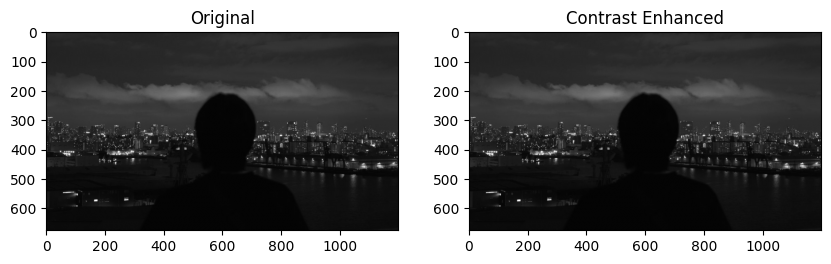

In [24]:
# write your code here
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
min_val = gray.min()
max_val = gray.max()

enhanced = (gray - min_val) / (max_val - min_val) * 255

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')

plt.title("Contrast Enhanced")
plt.show()

#Questions
#1.	Which image has better visibility of details?
# The "Enhanced" one is much better because the contrast is stretched, making the dark details easier to see.
#2.	Is this enhancement subjective or objective?
# It’s subjective. Even though the math is objective, deciding if an image looks "better" depends on the person looking at it.

## 7. Noise and image restoration
Noise removal is a core example of low level processing.

## **Exercise 7.1: Add artificial noise**

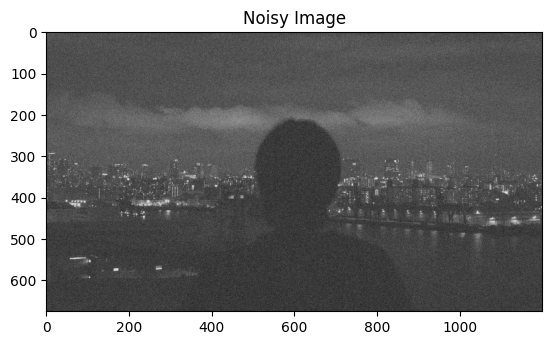

In [25]:
# write your code here

noise = np.random.normal(0, 20, gray.shape)
noisy = gray + noise

plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.show()

## **Exercise 7.2: Simple smoothing filter**

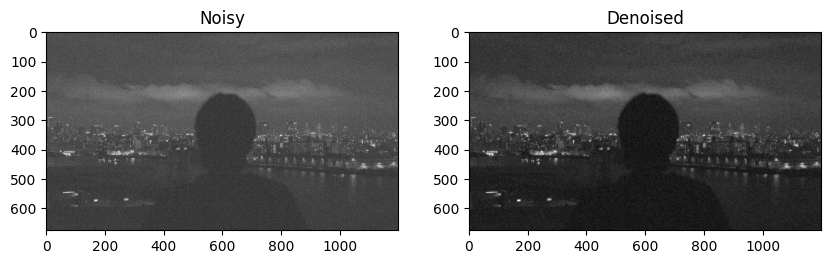

In [26]:
def mean_filter(img, k=3):
    pad = k // 2
    padded = np.pad(img, pad, mode='edge')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = padded[i:i+k, j:j+k].mean()
    return output

# complete the code here
denoised = mean_filter(noisy)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy")

plt.subplot(1,2,2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised")
plt.show()

## 8. From image processing to image analysis
The lecture distinguishes between low, mid, and high level processing.
## **Exercise 8.1: Simple threshold segmentation**

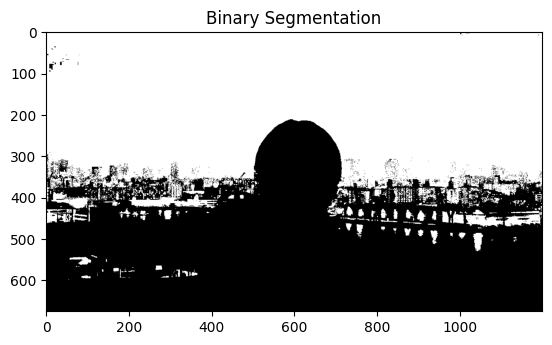

In [27]:
## write your code here
threshold = gray.mean()
binary = gray > threshold

plt.imshow(binary, cmap='gray')
plt.title("Binary Segmentation")
plt.show()


# Discussion:
# 1. Is this segmentation reliable?
# Not really. It separated the main object from the sky, but we lost all the background details and textures.
# 2. What information is lost when converting to binary?
#  We lose all the shades of gray. The image just becomes black and white, so we only see the basic shapes.

#**9. Mini project: connecting theory to practice**

**Task**

Using only NumPy and Matplotlib:

1.	Create a synthetic image containing at least two objects

2.	Add noise to the image

3.	Apply enhancement and denoising

4.	Segment the objects using a threshold

**Deliverables**

•	Code

•	Output images

•	Short explanation mapping each step to the image processing stages shown in the Chapter 1 pipeline diagram


***Note: Organize your project into logical steps using separate cells, include a Text Cell before each stage to explain your approach, and ensure all results are clearly visualized using titles and subplots***

In [28]:
import numpy as np
import matplotlib.pyplot as plt



Phase 1: Image Acquisition
Representing a digital image as a 2D matrix f(x,y) with intensity values for objects and background.

In [29]:
# step1: Creat synthetic image(base image)
img = np.zeros((100, 100))
#adding two differrnt shapes with different gray levels
img[15:45, 15:45]= 160
img[65:90, 60:85]= 230



Phase 2: Image Degradation
Simulating sensor noise (Gaussian noise) that occurs during the image capture process.

In [30]:
# step2: Add noise to the image
noise_factor=25
noise=np.random.normal(0, noise_factor, img.shape)
distorted_img = img + noise



Phase 3: Image Enhancement
Using a spatial filter (Mean filter) to reduce noise and improve the visual quality of the image

In [31]:
# step3: Apply enhancement and denoising

def apply_cleaning(src_img, k_size=3):
  offset = k_size // 2
  padded_img= np.pad(src_img, offset, mode='edge')
  clean_img = np.zeros_like(src_img)
  for r in range(src_img.shape[0]):
    for c in range(src_img.shape[1]):
      clean_img[r, c] = padded_img[r:r+k_size, c:c+k_size].mean()
  return clean_img
restored_img = apply_cleaning(distorted_img, k_size=5)




Phase 4: Image Segmentation
Extracting objects from the background using a global threshold to create a binary image.

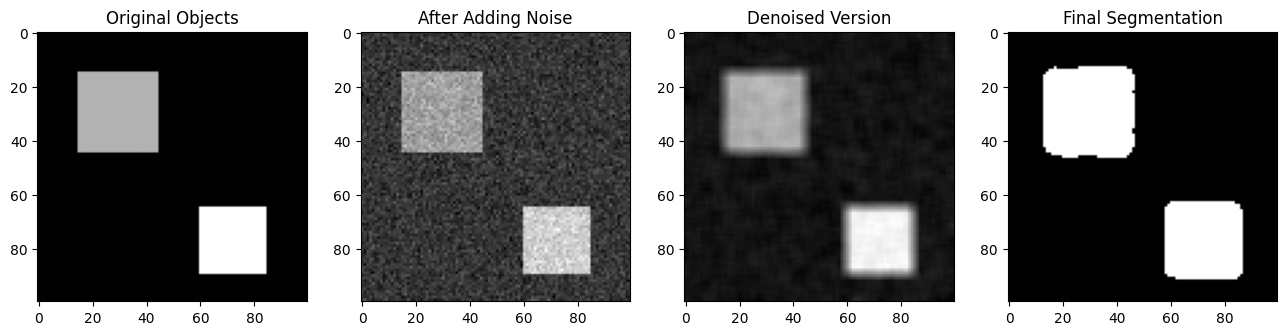

In [32]:
# Step4: segmentation

limit = restored_img.mean()
binary_result = restored_img > limit

fig, axes = plt.subplots(1, 4, figsize=(16,5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Objects')

axes[1].imshow(distorted_img, cmap='gray')
axes[1].set_title('After Adding Noise')

axes[2].imshow(restored_img, cmap='gray')
axes[2].set_title('Denoised Version')

axes[3].imshow(binary_result, cmap='gray')
axes[3].set_title('Final Segmentation')

plt.show()
